In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [6]:
df = pd.read_csv(r"D:\DA_BA Projects\Python\Python_Diwali_Sales_Analysis-main\Diwali Sales Data.csv",encoding="unicode_escape")

In [7]:
df.shape

(11251, 15)

In [8]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [10]:
df.drop(['Status','unnamed1'], axis=1 , inplace=True)

In [13]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [14]:
df.dropna(inplace=True)

In [15]:
df.shape

(11239, 13)

In [17]:
df['Amount'] = df['Amount'].astype('int')

In [18]:
df['Amount'].dtypes

dtype('int32')

In [20]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


### Gender

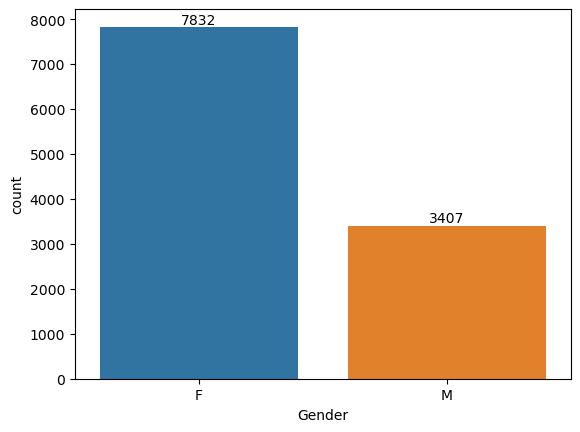

In [26]:
ax = sns.countplot(x = 'Gender',data = df,hue = 'Gender')

for bars in ax.containers:
    ax.bar_label(bars)
    
plt.show()

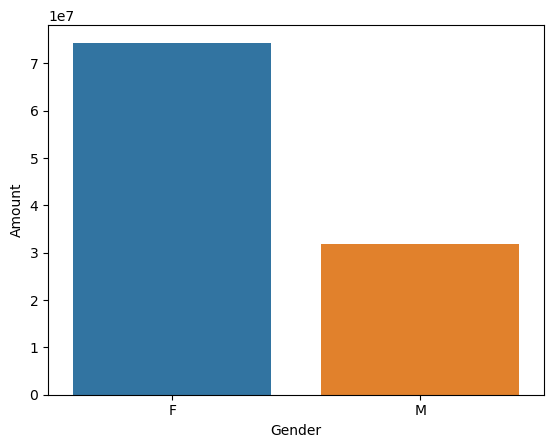

In [30]:
sales_gen = df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.barplot(x='Gender',y='Amount',data=sales_gen, hue='Gender')

plt.show()

From above graphs,we can see that the most of the buyers are females and even the purchasing power of females are greater than mens.

### Age

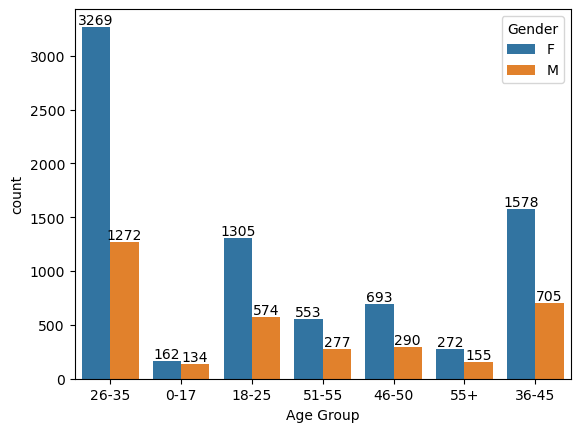

In [36]:
ax = sns.countplot(data = df,x = 'Age Group', hue= 'Gender')

for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

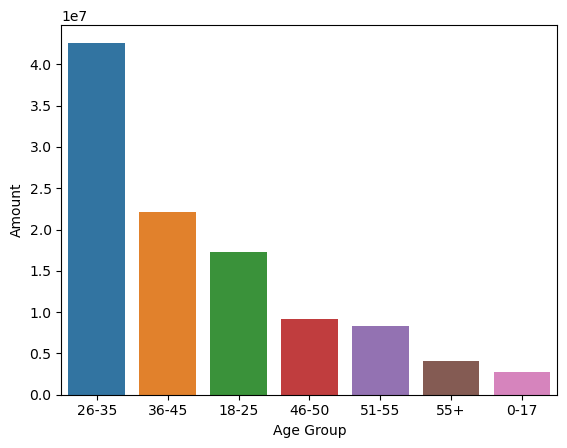

In [39]:
sales_age = df.groupby(['Age Group'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.barplot(x = 'Age Group',y ='Amount',  data = sales_age, hue='Age Group')

plt.show()

From above graphs we can see that most of the buyers are of age group between "26-35 years" females.

### State

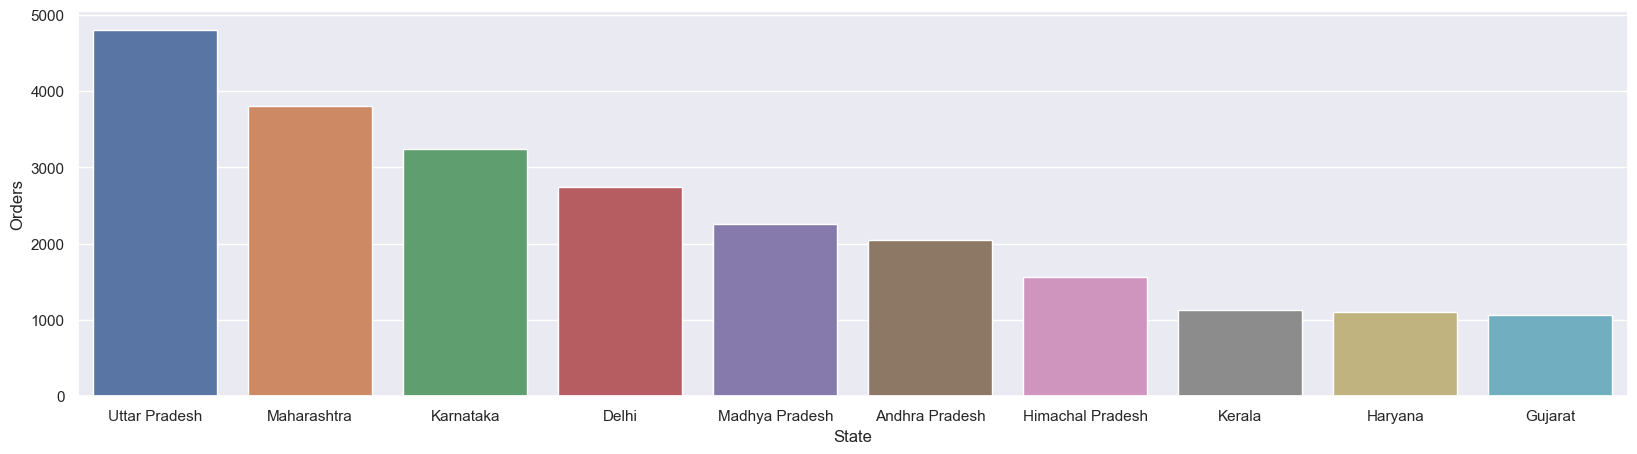

In [46]:
sales_state = df.groupby(['State'],as_index = False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x ='State',y='Orders', hue='State')

plt.show()

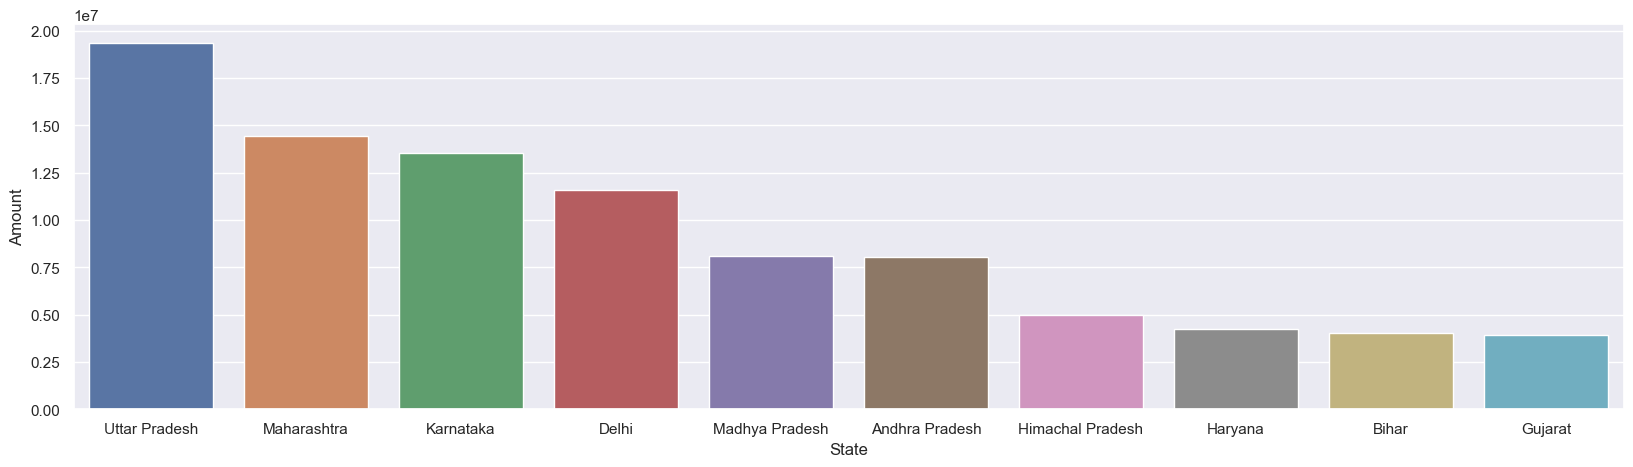

In [47]:
sales_state = df.groupby(['State'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x ='State',y='Amount', hue='State')

plt.show()

From above graphs,we can see that most of the Orders & Sales are from Uttar Pradesh, Maharashtra & Karnataka respectively.

### Marital Status

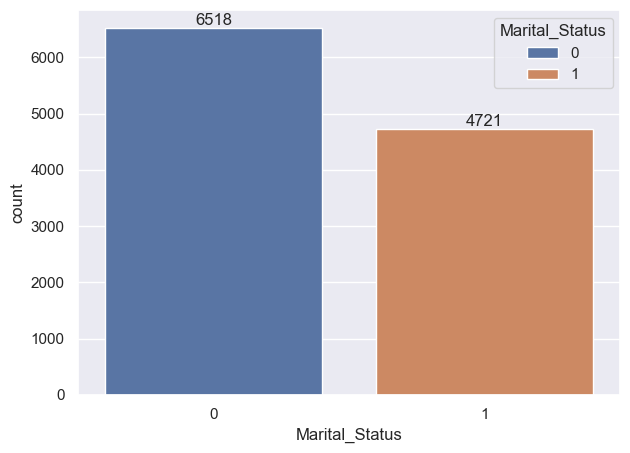

In [52]:
ax = sns.countplot(data=df ,x='Marital_Status', hue='Marital_Status')

sns.set(rc={'figure.figsize':(7,5)})
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

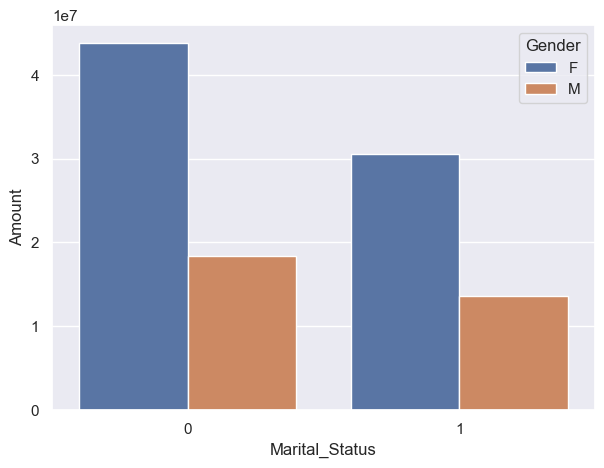

In [56]:
sales_marital_status = df.groupby(['Marital_Status','Gender'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.set(rc={'figure.figsize':(7,5)})
sns.barplot(data = sales_marital_status, x ='Marital_Status',y='Amount', hue='Gender')

plt.show()

In [ ]:
From above graphs,we can see that the most of the buyers are married (women) and they have high purchasing power

### Occupation

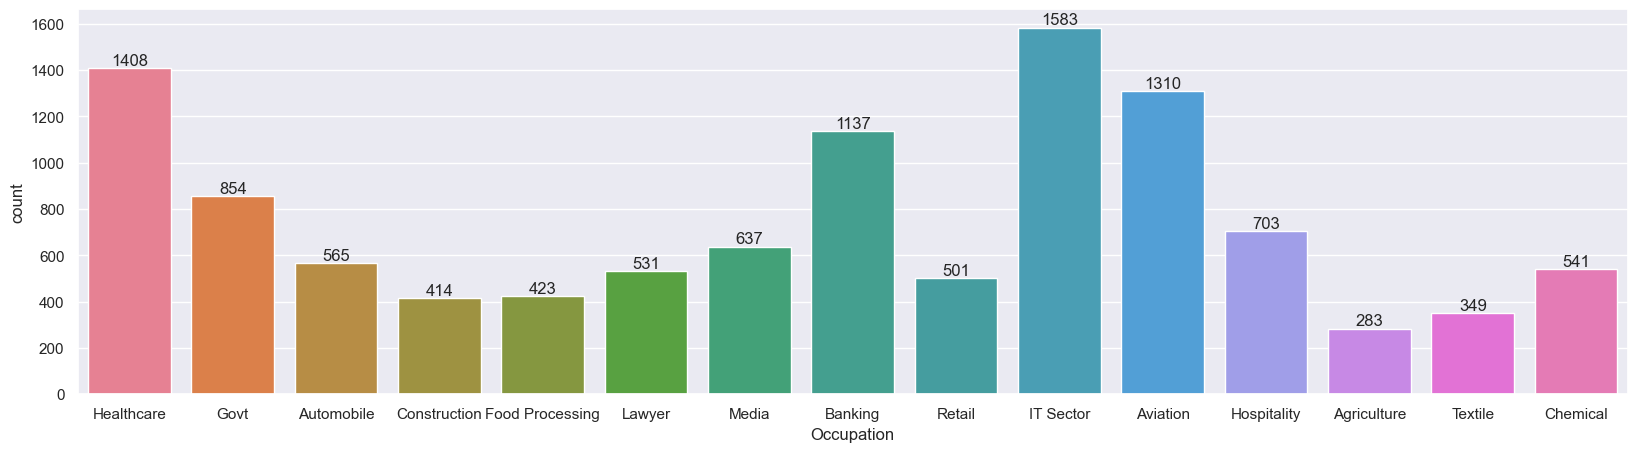

In [59]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data= df , x='Occupation', hue='Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

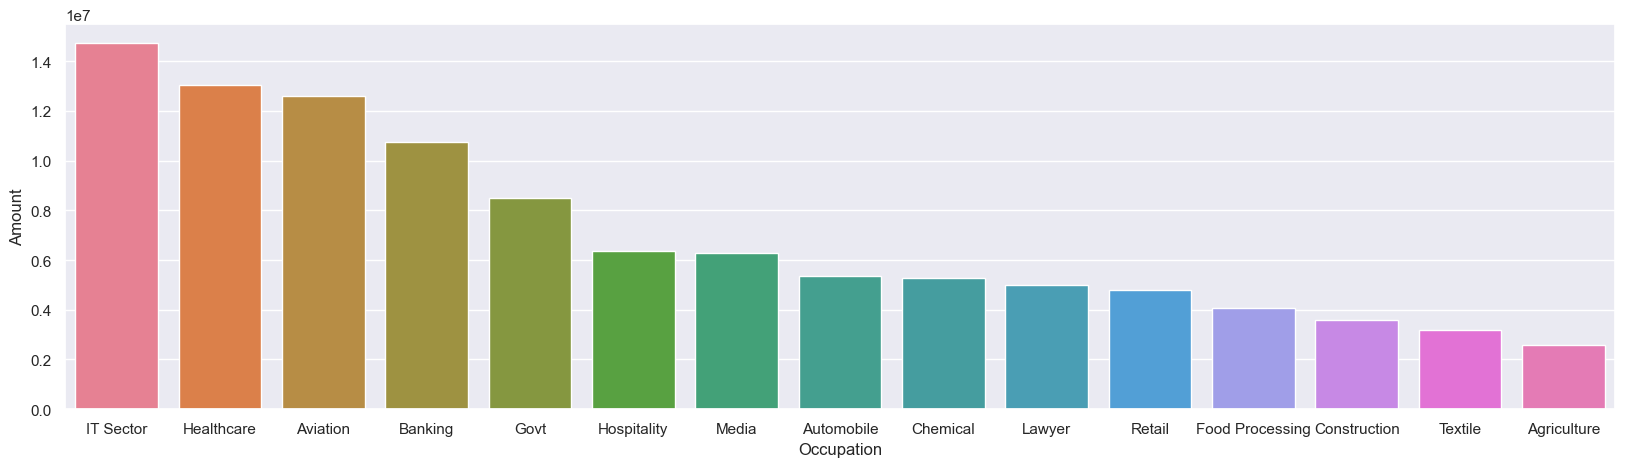

In [61]:
sales_occupation = df.groupby(['Occupation'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_occupation, x ='Occupation',y='Amount',hue ='Occupation')

plt.show()

From above graphs,we can see that the most of the buyers are working in IT,Healthcare and Aviation sector.

### Product Category

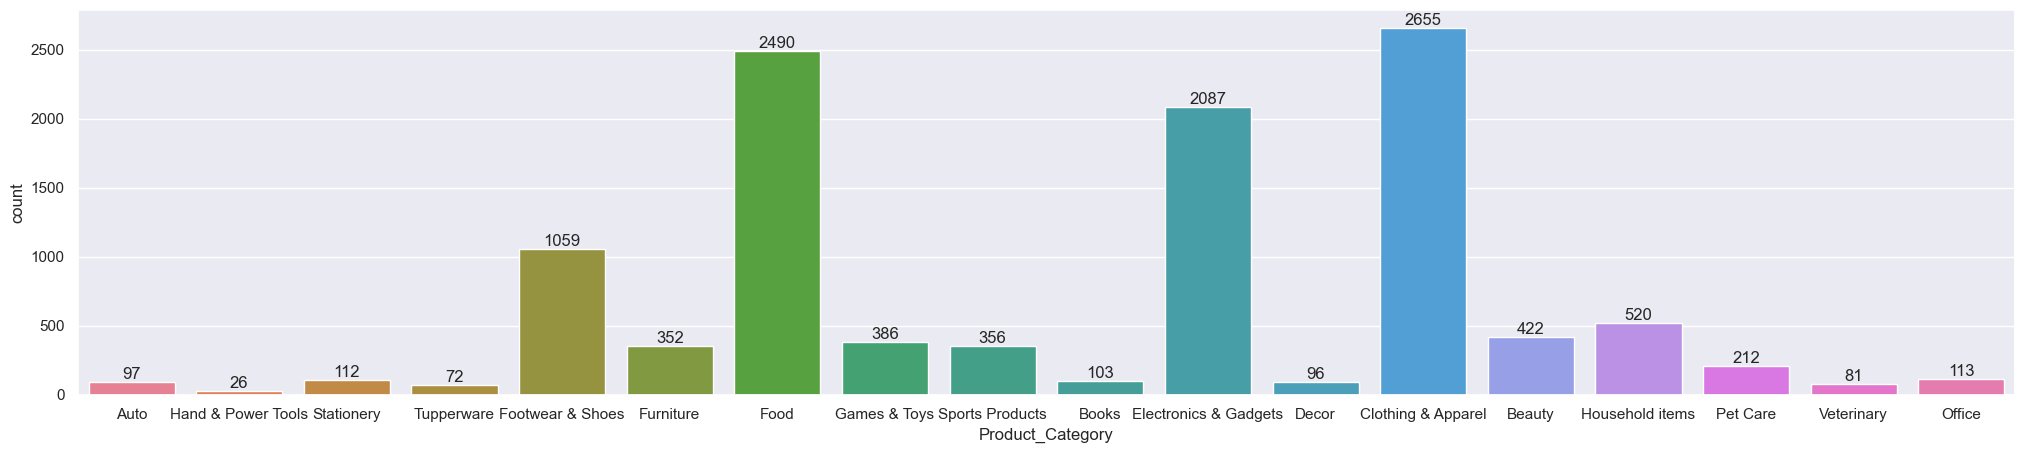

In [64]:
sns.set(rc={'figure.figsize':(25,5)})
ax = sns.countplot(data= df , x='Product_Category', hue='Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

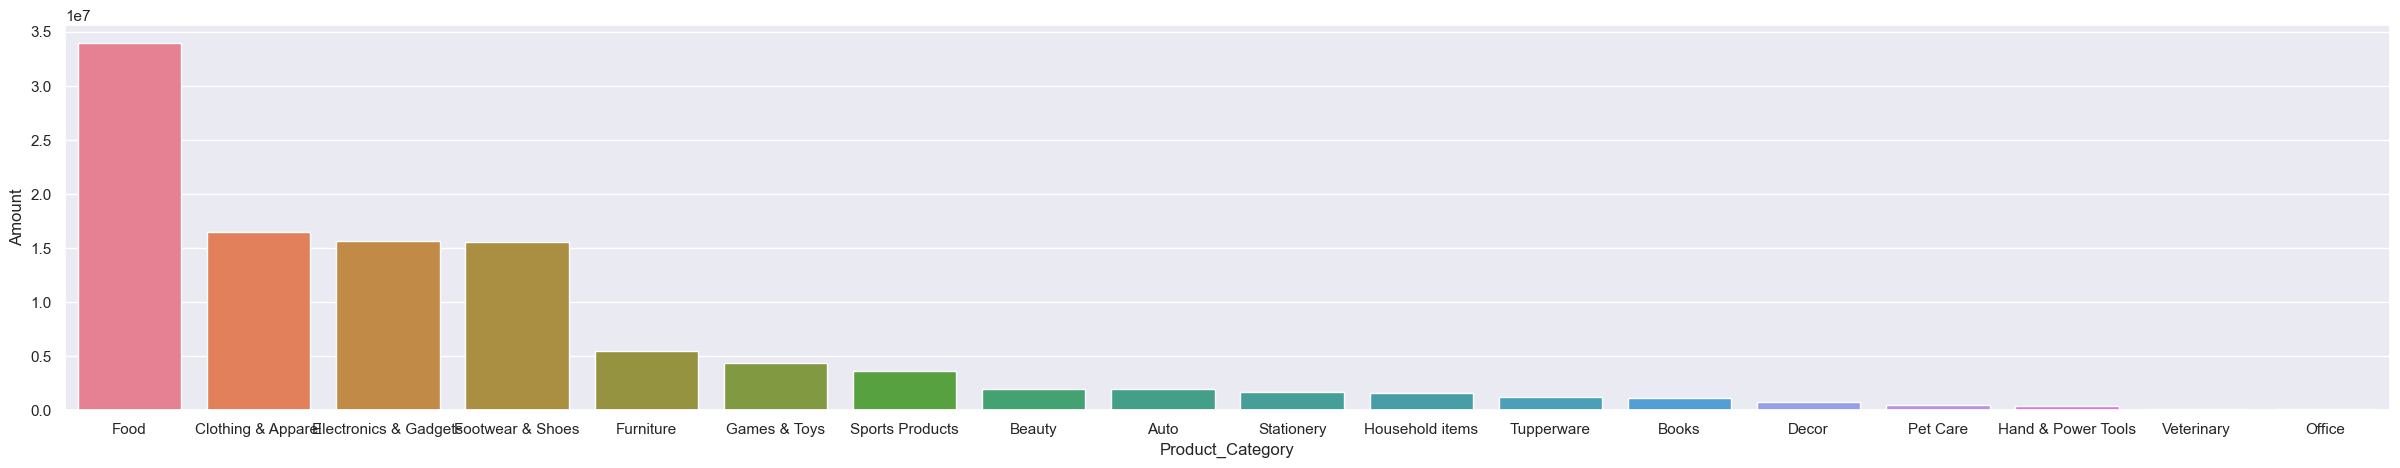

In [67]:
sales_product_category = df.groupby(['Product_Category'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False)

sns.set(rc={'figure.figsize':(30,5)})
sns.barplot(data = sales_product_category, x ='Product_Category',y='Amount',hue ='Product_Category')

plt.show()

From above graphs,we can see that the most of the sold products are from Food,Clothing & Apparel and Electronics category.

### Product ID

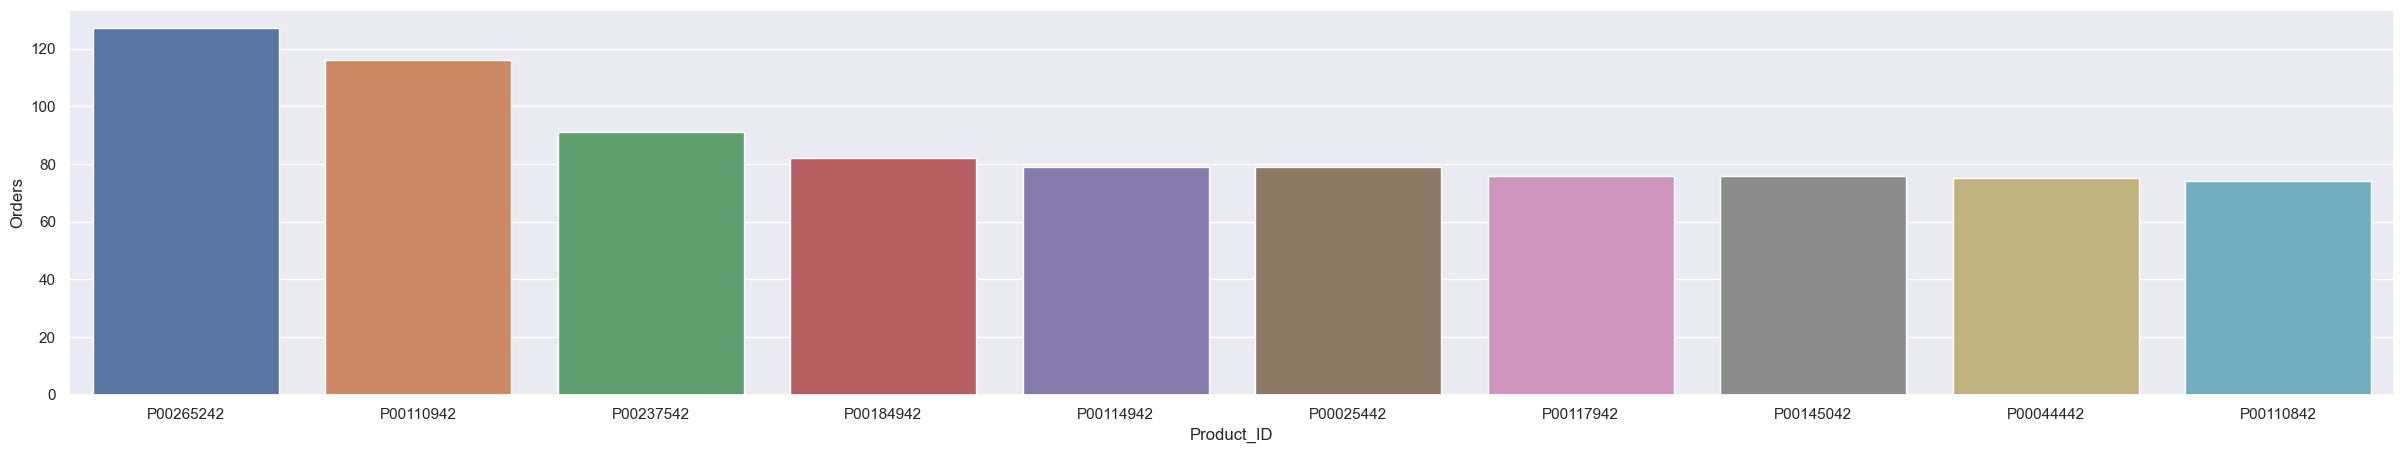

In [73]:
sales_product_id = df.groupby(['Product_ID'],as_index = False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)

sns.set(rc={'figure.figsize':(30,5)})
sns.barplot(data = sales_product_id, x ='Product_ID',y='Orders',hue='Product_ID')

plt.show()

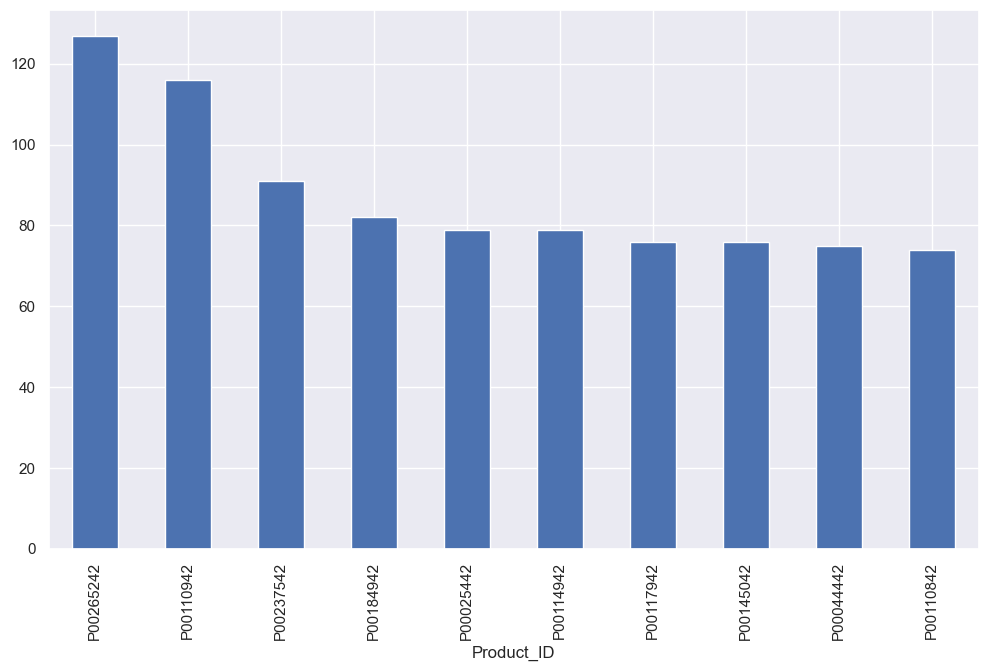

In [77]:
fig1,ax1 = plt.subplots(figsize=(12,7))
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

plt.show()

### Conclusion:

Married womens from age group 26-35 years from UP,Maharashtra and Karnataka working in IT,Healthcare and Aviation sectors are more likely to buy products from Food,Clothing & Apparels and Electronics Category.